# Superstore Project 
Dataset containing Sales & Profits of a Superstore

-- Business Statistics & Insights | Master in Business Analytics & AI

The goal is to use the Superstore Sales dataset (9,994 transactions, 2014–2017) not just to complete the assignment, but to produce work that directly maps to the five skill areas in the target role. Each section below defines the analysis, the method, the business framing, and the free tool to use.

* Dataset: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

<img src="https://quivo.co/fileadmin/_processed_/8/b/csm_Online-Shop_big_e8834fc4db.jpg" width="1500">

### Task 3 - Statistical Inference

Methodology Notes: 

With n = 9,994 observations, almost every statistical test will return p < 0.05. A large sample makes it easy to detect tiny, practically meaningless differences. Throughout this analysis, statistical significance (p-value) is reported alongside effect size — the measure of how large the difference actually is. A finding is only business-relevant if it is both statistically significant and practically meaningful.

##### A1. Upload libraries and dataset

In [1]:
# Load libraries and data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet('../data/processed/superstore_clean.parquet')
print(f"{df.shape[0]} rows loaded")

9994 rows loaded


#### 3.A — Confidence Intervals

A confidence interval answers: "What range of values is plausible for the true population mean?"

In [2]:
from scipy.stats import t

def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = data.mean()
    se = stats.sem(data)  # standard error
    margin = se * t.ppf((1 + confidence) / 2, df=n - 1)
    return mean, mean - margin, mean + margin

variables = {
    'Sales':         df['Sales'],
    'Profit':        df['Profit'],
    'Profit Margin': df['Profit Margin'],
    'Delivery Days': df['Delivery Days']
}

print(f"{'Variable':<20} {'Mean':>10} {'95% CI Lower':>14} {'95% CI Upper':>14}")
print("-" * 60)
for name, data in variables.items():
    mean, lo, hi = confidence_interval(data)
    print(f"{name:<20} {mean:>10.2f} {lo:>14.2f} {hi:>14.2f}")

Variable                   Mean   95% CI Lower   95% CI Upper
------------------------------------------------------------
Sales                    229.86         217.64         242.08
Profit                    28.66          24.06          33.25
Profit Margin              0.12           0.11           0.13
Delivery Days              3.96           3.92           3.99


Visualize them

##### 3.A.1. Visualize the confidence intervals for Sales, Profit, Profit Margin and Delivery Days

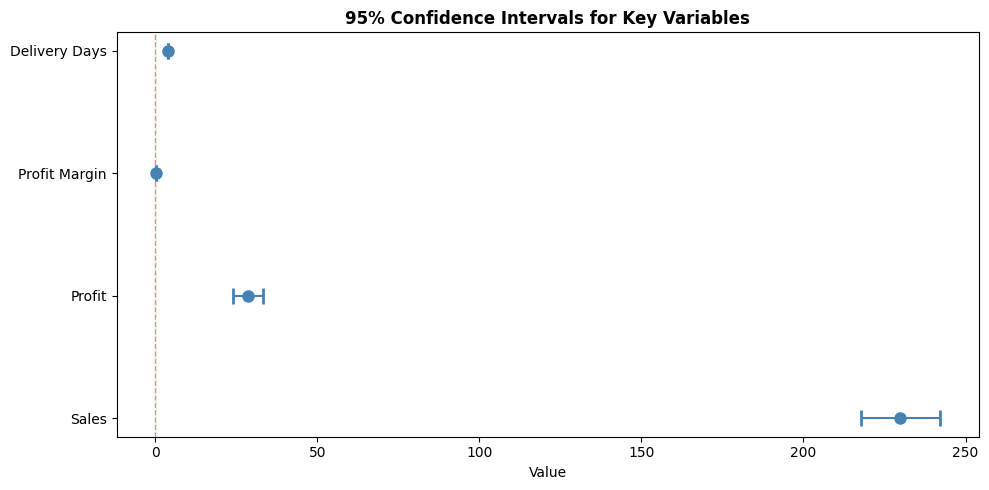

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

results = []
for name, data in variables.items():
    mean, lo, hi = confidence_interval(data)
    results.append({'Variable': name, 'Mean': mean, 'Lower': lo, 'Upper': hi})

ci_df = pd.DataFrame(results)

for i, row in ci_df.iterrows():
    ax.errorbar(row['Mean'], row['Variable'],
                xerr=[[row['Mean'] - row['Lower']], [row['Upper'] - row['Mean']]],
                fmt='o', color='steelblue', capsize=6, capthick=2, markersize=8)

ax.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('95% Confidence Intervals for Key Variables', fontweight='bold')
ax.set_xlabel('Value')
plt.tight_layout()
plt.savefig('../output/images/03_confidence_intervals.png', dpi=150, bbox_inches='tight')
plt.show()

With 95% confidence, the true mean sales per transaction lies between $218 and $242. Despite the substantial variability observed in individual transactions, the large sample size (n = 9,994) results in relatively narrow confidence intervals by reducing the standard error of the mean. The 95% confidence interval for Profit Margin ranges from 11% to 13% and remains entirely positive, indicating that the average transaction is profitable and providing strong evidence of overall profitability at the aggregate business level. Nevertheless, the presence of loss-making transactions elsewhere in the distribution suggests that profitability is not uniform across all orders, products, or customer segments.

#### 3.B. Comparison of Means

In [4]:
from scipy.stats import normaltest

for col in ['Sales', 'Profit', 'Delivery Days']:
    stat, p = normaltest(df[col])
    print(f"{col}: p = {p:.4f} - {'NOT normal' if p < 0.05 else 'Normal'}")

Sales: p = 0.0000 - NOT normal
Profit: p = 0.0000 - NOT normal
Delivery Days: p = 0.0000 - NOT normal


* Sales → strongly right-skewed
* Profit → right-skewed with heavy tails
* Delivery Days → discrete and likely skewed

Although Sales, Profit, and Delivery Days are not normally distributed according to D'Agostino and Pearson's normality test (p < 0.001), the large sample size (n = 9,994) allows the Central Limit Theorem to apply. Consequently, the sampling distribution of the mean is approximately normal, making the reported 95% confidence intervals reliable despite the strong skewness and heavy tails present in the underlying data.

##### 3.B.1. Comparison 1: Does profit differ between West and Central regions?

The Mann-Whitney U test (also known as the Wilcoxon rank-sum test) is a non-parametric statistical test used to determine whether there is a statistically significant difference between two independent groups. 
* It is the non-parametric equivalent of the independent t-test. When to Use It? 
    * You should use this test over an independent t-test when your data violates the assumptions of parametric tests, meaning: 
    * Non-normally distributed data: Your dependent variable is heavily skewed or does not follow a bell curve.
    * Ordinal data: The data consists of ranks or ratings (e.g., pain scale 1-10) rather than continuous measurements.
    * Outliers: Your data contains extreme outliers that would skew the mean.
    * Small sample sizes: You have limited data, usually less than 30 participants per group.

In [5]:
from scipy.stats import mannwhitneyu

west    = df[df['Region'] == 'West']['Profit']
central = df[df['Region'] == 'Central']['Profit']

stat, p = mannwhitneyu(west, central, alternative='two-sided')

# Effect size: rank-biserial correlation
n1, n2 = len(west), len(central)
r = 1 - (2 * stat) / (n1 * n2)

print(f"West median profit:    ${west.median():.2f}")
print(f"Central median profit: ${central.median():.2f}")
print(f"Mann-Whitney U: {stat:.0f}")
print(f"p-value: {p:.4f}")
print(f"Effect size (r): {r:.3f}  {'small' if abs(r)<0.3 else 'medium' if abs(r)<0.5 else 'large'}")

West median profit:    $11.17
Central median profit: $5.18
Mann-Whitney U: 4590569
p-value: 0.0000
Effect size (r): -0.234  small


The West region exhibits significantly higher profit per transaction than the Central region (median profit: $11.17 vs. $5.18). A Mann-Whitney U test confirmed that the difference in profit distributions is statistically significant (p < 0.001). However, the effect size is small (|r| = 0.234), indicating that although the difference is consistent across many transactions, the magnitude of the advantage is modest. Consequently, regional location appears to influence profitability, but it is unlikely to be the primary driver of profit variation compared with factors such as product category, discounting, or customer segment.

##### 3.B.2. Comparison 2 - Does sales differ between Consumer and Corporate Segments?

In [6]:
consumer  = df[df['Segment'] == 'Consumer']['Sales']
corporate = df[df['Segment'] == 'Corporate']['Sales']

stat, p = mannwhitneyu(consumer, corporate, alternative='two-sided')
r = 1 - (2 * stat) / (len(consumer) * len(corporate))

print(f"Consumer median sales:  ${consumer.median():.2f}")
print(f"Corporate median sales: ${corporate.median():.2f}")
print(f"p-value: {p:.4f}")
print(f"Effect size (r): {r:.3f}  {'small' if abs(r)<0.3 else 'medium' if abs(r)<0.5 else 'large'}")

Consumer median sales:  $53.72
Corporate median sales: $56.54
p-value: 0.4712
Effect size (r): 0.010  small


A Mann-Whitney U test was conducted to compare sales between Consumer and Corporate customers. The test found no statistically significant difference between the two segments (p = 0.471). Median sales were similar for Consumer ($53.72) and Corporate ($56.54) customers. The effect size was negligible (r = 0.010), indicating that customer segment has little influence on transaction-level sales. Therefore, there is insufficient evidence to conclude that sales behavior differs meaningfully between Consumer and Corporate customers.

##### 3.B.3. Comparison 3 - Does delivery time differ by Ship Mode?

In [7]:
ship_modes = df['Ship Mode'].unique()
print("Median delivery days by ship mode:")
print(df.groupby('Ship Mode')['Delivery Days'].median().sort_values())

# Test the two extremes
same_day  = df[df['Ship Mode'] == 'Same Day']['Delivery Days']
standard  = df[df['Ship Mode'] == 'Standard Class']['Delivery Days']

stat, p = mannwhitneyu(same_day, standard, alternative='two-sided')
r = 1 - (2 * stat) / (len(same_day) * len(standard))

print(f"\nSame Day vs Standard Class:")
print(f"p-value: {p:.4f}")
print(f"Effect size (r): {r:.3f}")

Median delivery days by ship mode:
Ship Mode
Same Day          0.0
First Class       2.0
Second Class      3.0
Standard Class    5.0
Name: Delivery Days, dtype: float64

Same Day vs Standard Class:
p-value: 0.0000
Effect size (r): 1.000


Delivery performance differs substantially across shipping modes. Same Day shipments have a median delivery time of 0 days, compared with 5 days for Standard Class shipments. A Mann-Whitney U test confirmed that this difference is highly significant (p < 0.001), while the rank-biserial correlation reached its maximum value (r = 1.000), indicating complete practical separation between the two distributions. This result confirms that shipping mode is the primary determinant of delivery speed and that the service levels offered by the company are clearly differentiated in operational performance.

#### 3.C. ANOVA - Analysis of Variance

A standard ANOVA (Analysis of Variance) assumes the data is "normally distributed" (a bell curve). However, financial data—especially Profit—is rarely "normal." It is usually skewed by extreme outliers (very large wins or very large losses).
* ANOVA tests whether means differ across more than two groups simultaneously. Use it for Region (4 groups) and Segment (3 groups).
* Since the data isn't normal, we will use Kruskal-Wallis (non-parametric ANOVA)

* ANOVA (Parametric): Compares the means (averages). It fails if the data is skewed.
* Kruskal-Wallis (Non-Parametric): Compares the ranks (medians). It is the "safe" version of ANOVA that doesn't care if your data is messy or skewed.

In [8]:
from scipy.stats import kruskal
from itertools import combinations

# ANOVA 1: Profit across all 4 Regions
groups_region = [df[df['Region'] == r]['Profit'].values for r in df['Region'].unique()]
stat, p = kruskal(*groups_region)
print(f"Kruskal-Wallis — Profit by Region")
print(f"H-statistic: {stat:.2f}, p-value: {p:.4f}")
print(f"Conclusion: {'Significant difference exists' if p < 0.05 else 'No significant difference'}\n")

# ANOVA 2: Sales across all 3 Segments
groups_segment = [df[df['Segment'] == s]['Sales'].values for s in df['Segment'].unique()]
stat, p = kruskal(*groups_segment)
print(f"Kruskal-Wallis — Sales by Segment")
print(f"H-statistic: {stat:.2f}, p-value: {p:.4f}")
print(f"Conclusion: {'Significant difference exists' if p < 0.05 else 'No significant difference'}")

Kruskal-Wallis — Profit by Region
H-statistic: 227.90, p-value: 0.0000
Conclusion: Significant difference exists

Kruskal-Wallis — Sales by Segment
H-statistic: 0.68, p-value: 0.7103
Conclusion: No significant difference


##### 3.C.1. Post-hoc pairwise tests with Bonferroni correction

In [9]:
from scipy.stats import mannwhitneyu

print("\nPost-hoc pairwise tests — Profit by Region (Bonferroni corrected):")
regions = df['Region'].unique()
pairs = list(combinations(regions, 2))
alpha_corrected = 0.05 / len(pairs)  # Bonferroni correction

for r1, r2 in pairs:
    g1 = df[df['Region'] == r1]['Profit']
    g2 = df[df['Region'] == r2]['Profit']
    stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
    sig = '✓ SIGNIFICANT' if p < alpha_corrected else '✗ not significant'
    print(f"  {r1} vs {r2}: p={p:.4f} {sig}")

print(f"\n(Bonferroni corrected α = {alpha_corrected:.4f})")


Post-hoc pairwise tests — Profit by Region (Bonferroni corrected):
  South vs West: p=0.0002 ✓ SIGNIFICANT
  South vs Central: p=0.0000 ✓ SIGNIFICANT
  South vs East: p=0.0185 ✗ not significant
  West vs Central: p=0.0000 ✓ SIGNIFICANT
  West vs East: p=0.0000 ✓ SIGNIFICANT
  Central vs East: p=0.0000 ✓ SIGNIFICANT

(Bonferroni corrected α = 0.0083)


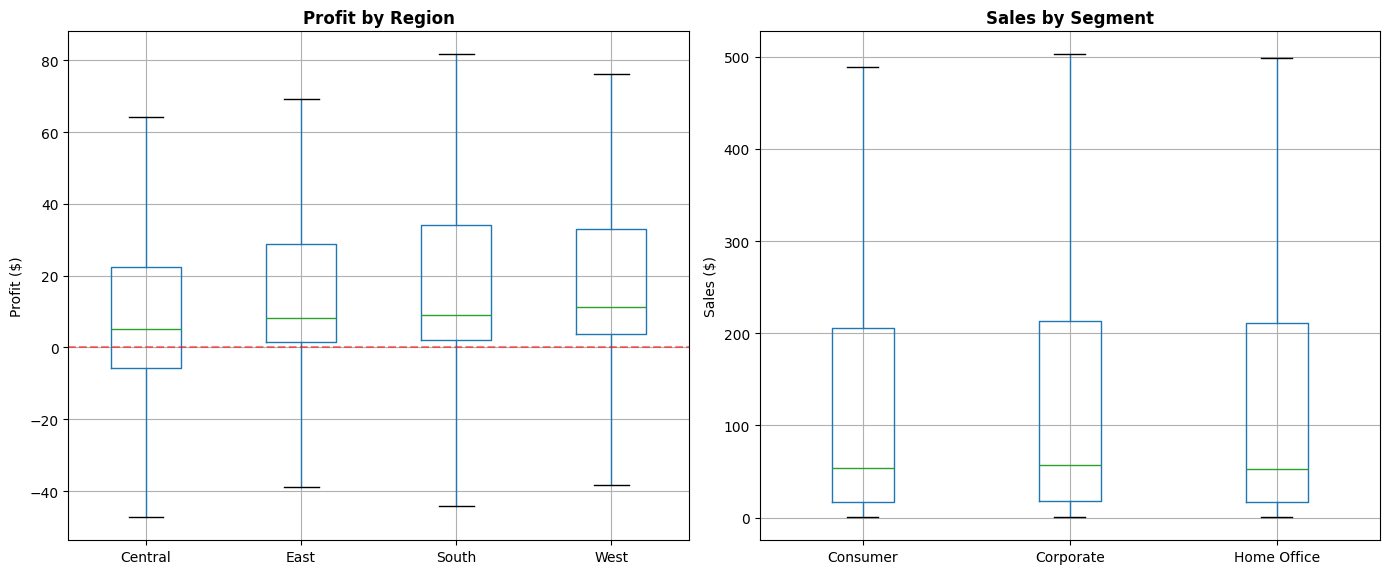

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Profit by Region
df.boxplot(column='Profit', by='Region', ax=axes[0],
           showfliers=False)  # hide outliers for readability
axes[0].set_title('Profit by Region', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Profit ($)')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)

# Sales by Segment
df.boxplot(column='Sales', by='Segment', ax=axes[1], showfliers=False)
axes[1].set_title('Sales by Segment', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Sales ($)')

plt.suptitle('')
plt.tight_layout()
plt.savefig('../output/images/03_anova_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

The Kruskal-Wallis test reveals a statistically significant difference in profit across the four regions (H = 227.90, p < 0.001). Post-hoc pairwise tests with Bonferroni correction (adjusted α = 0.0083) identify 5 out of 6 region pairs as significant sources of this difference: West vs Central, West vs East, Central vs East, South vs West, and South vs Central all show significant differences in profit. The only non-significant pair is South vs East (p = 0.0185), suggesting these two regions have comparable profit distributions. The West region is the standout performer, differing significantly from all other regions, while Central is the weakest, also differing significantly from all others. However, as noted in the pairwise comparison (effect size r = 0.234, small), the practical magnitude of these differences is modest — the statistical significance is partly driven by the large sample size (n = 9,994), and findings should be interpreted with that context in mind.

#### 3.D. Chi-Square-Test 

Chi-square tests whether two categorical vaiables are independent. 
* Business Question? Do certain customer segments gravitate toward certain product categories?

##### 3.D.1. Chi-square for Segment and Category

In [11]:
from scipy.stats import chi2_contingency

# Contingency table: Segment x Category
contingency = pd.crosstab(df['Segment'], df['Category'])
print("Observer frequencies:")
print(contingency)


chi2, p, dof, expected = chi2_contingency(contingency)

print(f"\nChi-square statistics: {chi2:.2f}")
print(f"Degress of freedom: {dof}")
print(f"p-value: {p:.4f}")
print(f"Conclusion: {'Dependent (association exists)' if p < 0.05 else 'Independent (no association)'}")


# Effect size: Cramer's V
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
print(f"Cramer's V (Effect size): {cramers_v:.3f} {'weak' if cramers_v < 0.1 else 'moderate' if cramers_v < 0.03 else 'strong'} ")

Observer frequencies:
Category     Furniture  Office Supplies  Technology
Segment                                            
Consumer          1113             3127         951
Corporate          646             1820         554
Home Office        362             1079         342

Chi-square statistics: 1.46
Degress of freedom: 4
p-value: 0.8335
Conclusion: Independent (no association)
Cramer's V (Effect size): 0.009 weak 


A Chi-square test of independence examined whether product category purchased is associated with customer segment. The test found no statistically significant association (χ² = 1.46, df = 4, p = 0.834). The effect size is negligible (Cramér's V = 0.009), confirming that the result is not merely non-significant but also practically absent. All three segments — Consumer, Corporate, and Home Office — purchase across Furniture, Office Supplies, and Technology in proportions that are essentially identical, with Office Supplies dominating in all cases (~64–65% of orders per segment). Customer segment does not predict product category preference, and targeting strategy should therefore be driven by other factors such as order value or profitability rather than category affinity.

##### 3.D.2. Chi-square for Discount Category vs Category

In [12]:
contingency2 = pd.crosstab(df['Discount Category'], df['Category'])
chi2, p, dof, expected = chi2_contingency(contingency2)
cramers_v2 = np.sqrt(chi2 / (contingency2.sum().sum() * (min(contingency2.shape) - 1)))

print(f"\nDiscount Category × Product Category:")
print(f"p-value: {p:.4f}, Cramér's V: {cramers_v2:.3f}")


Discount Category × Product Category:
p-value: 0.0000, Cramér's V: 0.230


##### 3.D.3. Visualize as a heatmap 

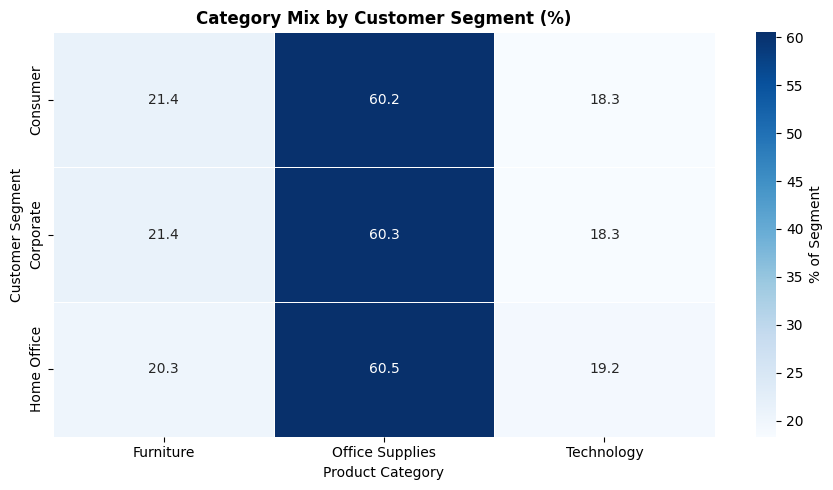

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

# Normalise by row to show proportions
contingency_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100

sns.heatmap(contingency_pct, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% of Segment'})
ax.set_title('Category Mix by Customer Segment (%)', fontweight='bold')
ax.set_xlabel('Product Category')
ax.set_ylabel('Customer Segment')

plt.tight_layout()
plt.savefig('../output/images/03_chisquare_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.E. Corr - Correlation

##### 3.E.1. Corr between discount and profit margin

Using Spearman (not Pearson) because the variables are not normally distributed — Spearman works on ranks and is robust to skew.

In [14]:
# Corr discount and profit margin

corr, p = stats.spearmanr(df['Discount'], df['Profit Margin'])
print(f"Spearman correlation — Discount vs Profit Margin:")
print(f"ρ = {corr:.3f}, p = {p:.4f}")
print(f"Interpretation: {'negative' if corr < 0 else 'positive'} correlation, {'strong' if abs(corr)>0.5 else 'moderate' if abs(corr)>0.3 else 'weak'}")

Spearman correlation — Discount vs Profit Margin:
ρ = -0.645, p = 0.0000
Interpretation: negative correlation, strong


A Spearman rank correlation was computed to assess the relationship between discount level and profit margin (both non-normally distributed). The result reveals a strong negative correlation (ρ = −0.645, p < 0.001), confirming that higher discounts are systematically associated with lower — and frequently negative — profit margins. This relationship is monotonic: as discount increases, profit margin consistently deteriorates across the dataset. The magnitude of ρ = −0.645 is notable given the noise inherent in transaction-level data, and indicates that discounting policy is one of the most influential drivers of margin erosion in this business. This is consistent with the earlier finding that orders with discounts above 40% account for the majority of loss-making transactions, particularly in Furniture sub-categories such as Tables and Bookcases.

##### 3.E.2. Visualize: Scatter of Discount vs Profit Margin, Average Profit Margin trend across 2014–2017 

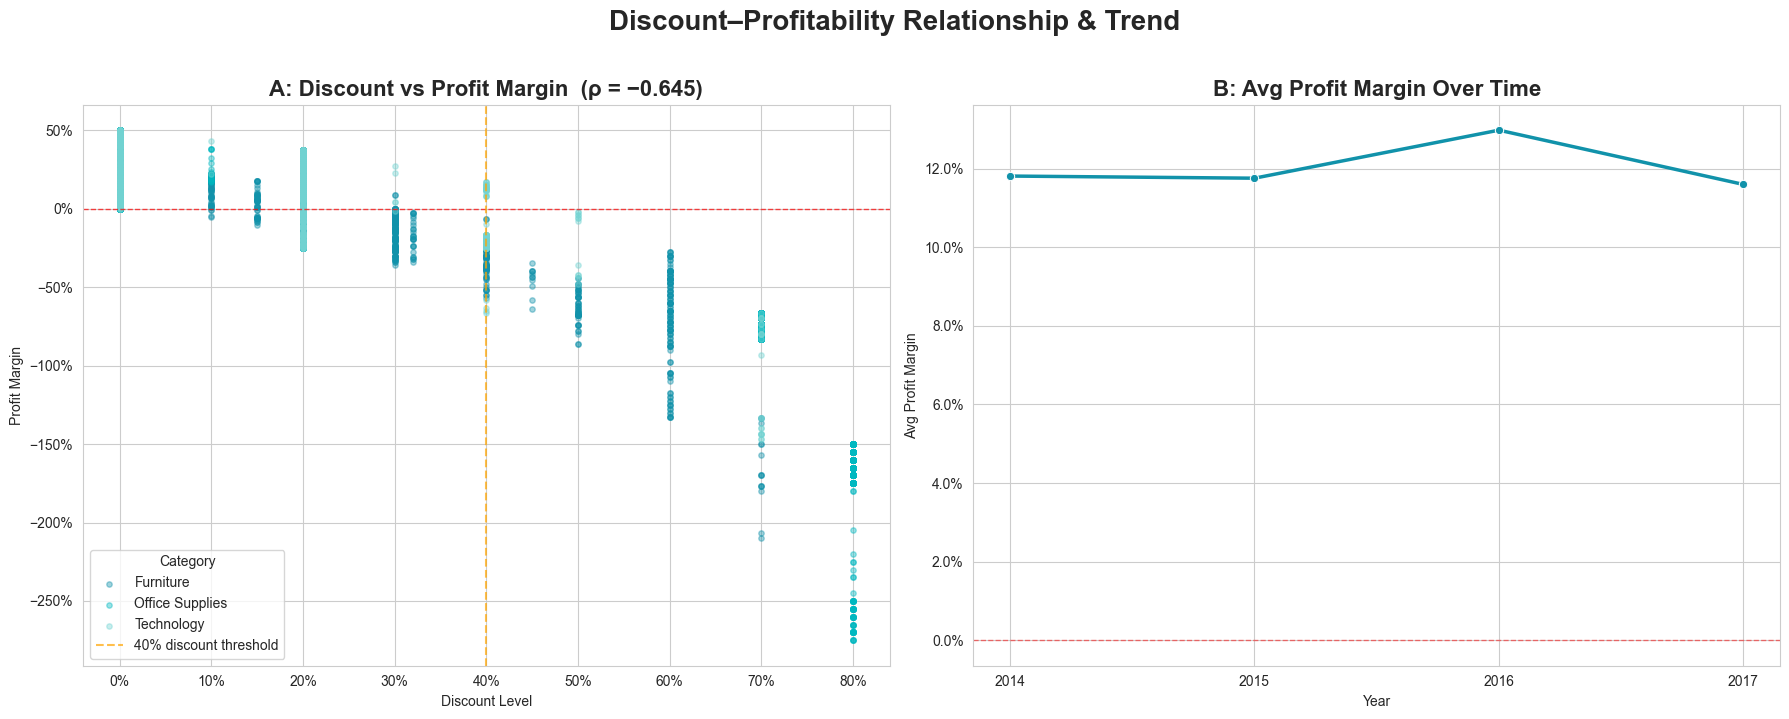

In [16]:

import os
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

# Discount vs Profit Margin
category_colors = {'Furniture': '#1192AA', 'Office Supplies': '#00B8C0', 'Technology': '#73D4D3'}

for cat, grp in df.groupby('Category'):
    axes[0].scatter(
        grp['Discount'],
        grp['Profit Margin'],
        label=cat,
        color=category_colors[cat],
        alpha=0.4,
        s=15
    )

axes[0].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[0].axvline(0.4, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='40% discount threshold')
axes[0].set_title("A: Discount vs Profit Margin  (ρ = −0.645)", fontsize=16, weight='bold')
axes[0].set_xlabel("Discount Level")
axes[0].set_ylabel("Profit Margin")
axes[0].legend(title='Category', loc='lower left')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

# Panel B: Average Profit Margin by Year 
yearly_margin = df.groupby('Year')['Profit Margin'].mean().reset_index()

sns.lineplot(
    data=yearly_margin,
    x='Year',
    y='Profit Margin',
    marker='o',
    color='#1192AA',
    linewidth=2.5,
    ax=axes[1]
)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_title("B: Avg Profit Margin Over Time", fontsize=16, weight='bold')
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Avg Profit Margin")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].set_xticks(yearly_margin['Year'])

plt.suptitle("Discount–Profitability Relationship & Trend", fontsize=20, weight='bold', y=1.02)
plt.tight_layout()
os.makedirs('../output/images', exist_ok=True)
plt.savefig('../output/images/03_discount_vs_margin.png', dpi=150, bbox_inches='tight')
plt.show()

##### 3.E.3. Save Resuls

In [18]:
import os

inference_summary = pd.DataFrame([
    {'Test': 'CI — Mean Sales',
     'Result': 'CI: [$217.64, $242.08]',
     'Significant': 'Yes',
     'Business Implication': 'Mean transaction value is stable and well-estimated; budget forecasting is reliable'},

    {'Test': 'Mann-Whitney — West vs Central Profit',
     'Result': 'p<0.001, r=0.234 (small)',
     'Significant': 'Yes',
     'Business Implication': 'West significantly more profitable than Central, but effect is small — not the primary driver'},

    {'Test': 'Kruskal-Wallis — Profit by Region',
     'Result': 'H=227.90, p<0.001 — 5/6 pairs significant',
     'Significant': 'Yes',
     'Business Implication': 'Regional profit differences are real; West leads, Central lags — resource allocation should reflect this'},

    {'Test': 'Kruskal-Wallis — Sales by Segment',
     'Result': 'H=0.68, p=0.710',
     'Significant': 'No',
     'Business Implication': 'Sales do not differ meaningfully across segments — all segments spend similarly per transaction'},

    {'Test': 'Chi-Square — Segment × Category',
     'Result': 'χ²=1.46, p=0.834, V=0.009',
     'Significant': 'No',
     'Business Implication': 'Segments show no category preference — cross-sell strategy cannot be driven by segment alone'},

    {'Test': 'Chi-Square — Discount × Category',
     'Result': 'p<0.001, V=0.230 (moderate)',
     'Significant': 'Yes',
     'Business Implication': 'Discounting is unevenly applied across categories — Furniture and Binders receive the heaviest discounts'},

    {'Test': 'Spearman — Discount vs Profit Margin',
     'Result': 'ρ=−0.645, p<0.001 (strong)',
     'Significant': 'Yes',
     'Business Implication': 'Discounting is the strongest driver of margin erosion — reducing high discounts is the clearest lever for profitability'},
])

os.makedirs('../output/kpis', exist_ok=True)
inference_summary.to_csv('../output/kpis/inference_summary.csv', index=False)
print("Saved inference_summary.csv")
inference_summary

Saved inference_summary.csv


,Test,Result,Significant,Business Implication
0,CI — Mean Sales,"CI: [$217.64, $242.08]",Yes,Mean transaction value is stable and well-esti...
1,Mann-Whitney — West vs Central Profit,"p<0.001, r=0.234 (small)",Yes,West significantly more profitable than Centra...
2,Kruskal-Wallis — Profit by Region,"H=227.90, p<0.001 — 5/6 pairs significant",Yes,Regional profit differences are real; West lea...
3,Kruskal-Wallis — Sales by Segment,"H=0.68, p=0.710",No,Sales do not differ meaningfully across segmen...
4,Chi-Square — Segment × Category,"χ²=1.46, p=0.834, V=0.009",No,Segments show no category preference — cross-s...
5,Chi-Square — Discount × Category,"p<0.001, V=0.230 (moderate)",Yes,Discounting is unevenly applied across categor...
6,Spearman — Discount vs Profit Margin,"ρ=−0.645, p<0.001 (strong)",Yes,Discounting is the strongest driver of margin ...


#### 3.F. Correlation Analysis (Pearson):  Relationships between variables

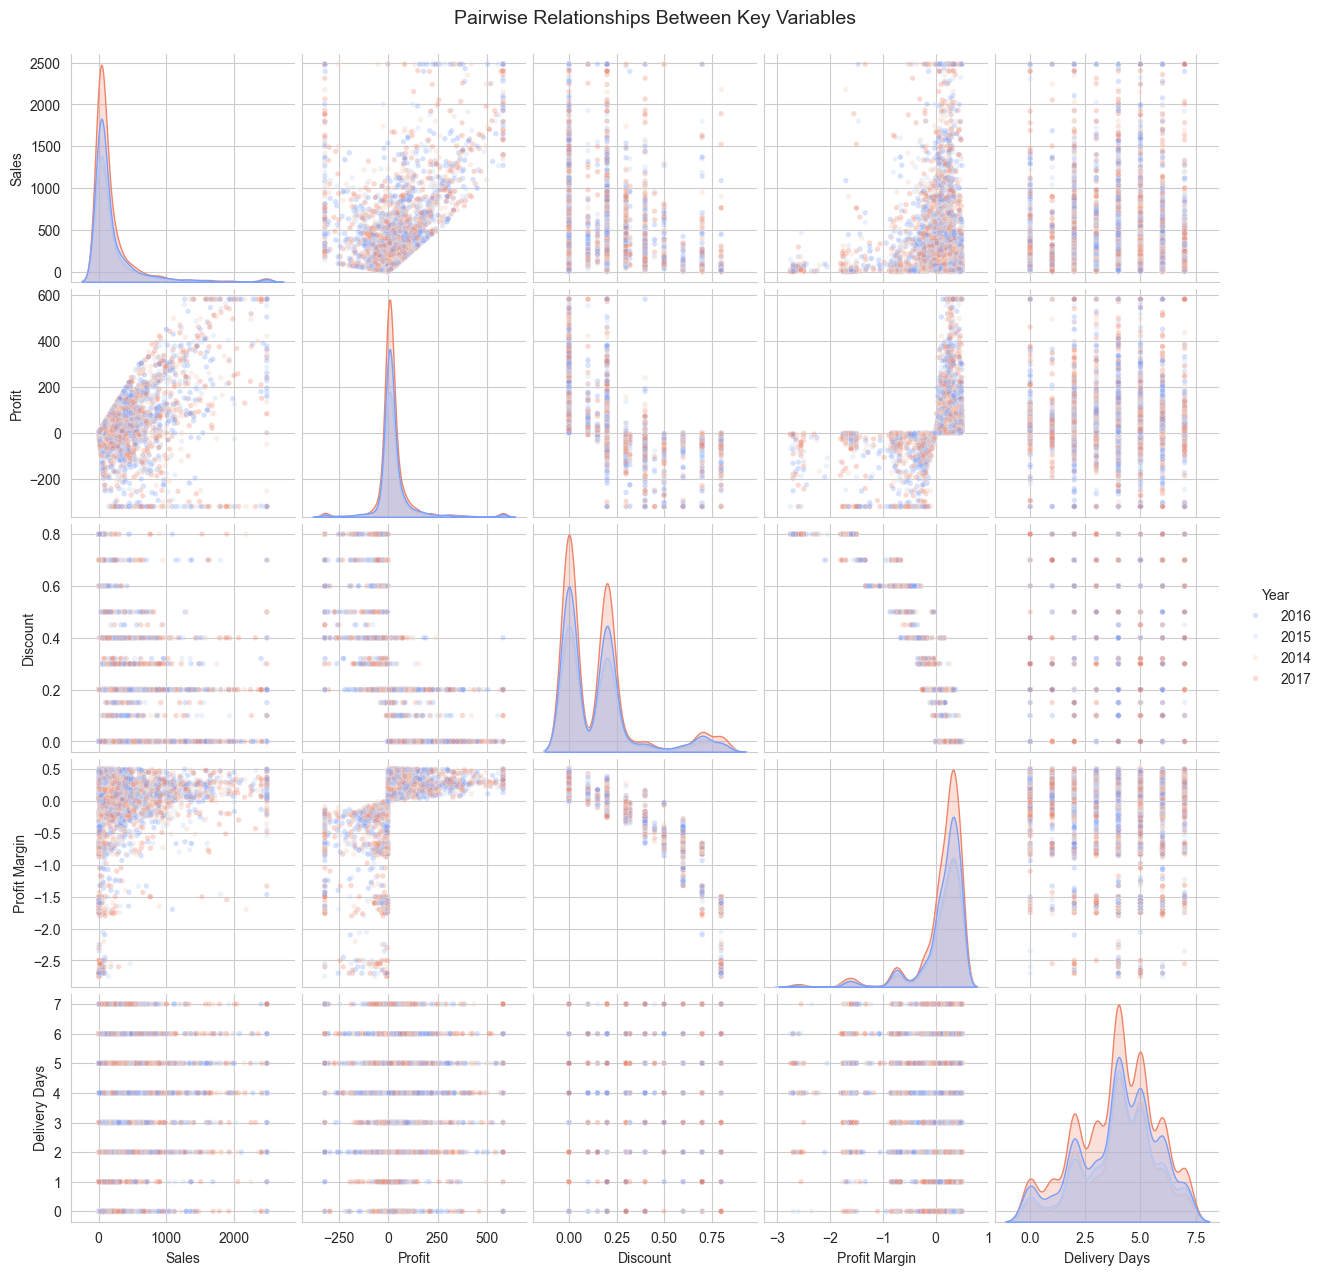

In [ ]:
# Define key variables
cols = ['Sales', 'Profit', 'Discount', 'Profit Margin', 'Delivery Days']

# Clip extreme outliers so plots are readable
df_plot = df[cols + ['Year']].copy()
df_plot['Sales']  = df_plot['Sales'].clip(upper=df['Sales'].quantile(0.99))
df_plot['Profit'] = df_plot['Profit'].clip(
    lower=df['Profit'].quantile(0.01),
    upper=df['Profit'].quantile(0.99)
)
df_plot['Year'] = df_plot['Year'].astype(str)

# Create the pairplot

g = sns.pairplot(
    df_plot,
    vars=cols,
    hue='Year',
    palette="coolwarm",
    plot_kws={'alpha': 0.3, 's': 15},
    diag_kind='kde'
)

g.figure.suptitle("Pairwise Relationships Between Key Variables", fontsize=14, y=1.02)
os.makedirs('../output/images', exist_ok=True)
plt.savefig('../output/images/03_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

The pairplot reveals four key patterns across the five variables, with year shown via coolwarm (blue = 2014, red = 2017):

**Discount × Profit Margin (strongest signal):** The most visually striking panel. As discount increases, profit margin drops sharply and consistently into negative territory. The fan-shaped scatter confirms the Spearman result (ρ = −0.645) — this is the single strongest pairwise relationship in the dataset and the clearest lever for improving profitability.

**Discount × Profit:** A similar pattern — higher discounts push individual transaction profit below zero. The density of points at specific discount levels (0%, 20%, 30%, 40%, etc.) reflects a discrete discount structure, not a continuous one.

**Sales × Profit:** A moderate positive relationship with wide spread. High-sales transactions tend to be profitable, but the relationship is noisy — large orders can still produce losses when heavily discounted. The long tail on Sales (even after 99th-percentile clipping) pulls some points far right.

**Delivery Days:** Essentially uncorrelated with every other variable. The scatter panels involving Delivery Days show no pattern — delivery speed is determined entirely by ship mode choice, not by order size, profitability, or discount level.

**Year (colour):** No visible clustering by year across any panel. The four years overlap almost completely, indicating that the structural relationships between these variables did not change materially from 2014 to 2017. Trends are subtle and only detectable at the aggregate level (as shown in the Avg Profit Margin by Year line chart).